# **EDA (Exploratory Data Analysis) and Feature Extraction**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import json
import re
from datetime import datetime
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import itertools
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


### **Feature Extraction**


In [ ]:
# Load JSON data (Fixed file path)
file_path = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Merged).json"

# file_path = "test.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

In [ ]:
with open(file_path, "r+", encoding="utf-8") as f:
    data = json.load(f)

In [ ]:
all_comments = [comment for user in data for comment in user.get("comments", [])]

In [ ]:
thread_map = defaultdict(list)
for comment in all_comments:
    thread_id = comment.get("parentCommentID", comment["commentID"])
    thread_map[thread_id].append(comment)

In [ ]:
print(f"Number of users: {len(data)}")
print(f"Number of comments: {len(all_comments)}")

Number of users: 325320
Number of comments: 728117


In [ ]:
# FEATURE: Average Comment Length

def compute_avg_comment_length(comments):
    if not comments:
        return 0.0
    total_length = sum(len(comment["commentText"]) for comment in comments if comment["commentText"])
    return total_length / len(comments) if len(comments) > 0 else 0.0

In [ ]:
# FEATURE: Average Link Usage

def compute_avg_link_usage(comments):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')  # Regex for URLs
    return sum(len(url_pattern.findall(comment["commentText"])) for comment in comments if comment["commentText"])

In [ ]:
# FEATURE: Average Response Time

def compute_avg_response_time(comments):
  response_times = []

  for comment in comments:
    comment_dt_str = f"{comment['commentDate']} {comment['commentTime']}"
    comment_dt = datetime.strptime(comment_dt_str, "%Y-%m-%d %H:%M:%S")


    if comment["isReply"]:
      parent_comment = next((c for c in all_comments if c["commentID"] == comment["parentCommentID"]), None)
      if parent_comment is not None:
        parent_dt_str = f"{parent_comment['commentDate']} {parent_comment['commentTime']}"
        parent_dt = datetime.strptime(parent_dt_str, "%Y-%m-%d %H:%M:%S")
        response_time = (comment_dt - parent_dt).total_seconds()
      else:
        post_dt_str = f"{comment['postDate']} {comment['postTime']}"
        post_dt = datetime.strptime(comment_dt_str, "%Y-%m-%d %H:%M:%S")
        response_time = (comment_dt - post_dt).total_seconds()

      if response_time >= 0:
        response_times.append(response_time)

    else:
      post_dt_str = f"{comment['postDate']} {comment['postTime']}"
      post_dt = datetime.strptime(comment_dt_str, "%Y-%m-%d %H:%M:%S")
      response_time = (comment_dt - post_dt).total_seconds()

      if response_time >= 0:
        response_times.append(response_time)

  if response_times:
    return sum(response_times)/ len(response_times)
  else:
    return 0

In [ ]:
# FEATURE: Engagement

def compute_total_engagement(comments):
    return sum(int(comment["likes"]) if isinstance(comment["likes"], (int, str)) and str(comment["likes"]).isdigit() else 0 for comment in comments)

In [ ]:
# FEATURE: Average Pairwise Text Dissimilarity

filipino_stopwords = {
    'ang', 'sa', 'ng', 'mga', 'na', 'ay', 'at', 'ni', 'kay', 'ito', 'iyon', 'kasi',
    'pero', 'dahil', 'hindi', 'siya', 'sila', 'kami', 'tayo', 'ako', 'ikaw', 'mo', 'ko',
    'wala', 'meron', 'may', 'nga', 'nang', 'rin', 'din', 'pa', 'ba', 'lahat', 'lamang'
}

merged_stopwords = list(filipino_stopwords.union(ENGLISH_STOP_WORDS))

def remove_non_text_characters(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

def compute_avg_text_sim(comments):
    texts = []
    for comment in comments:
        raw = comment.get("commentText")
        if raw is None or not isinstance(raw, str):
            continue

        raw = raw.strip().lower()

        cleaned = remove_non_text_characters(raw)
        tokens = cleaned.split()
        filtered_tokens = [t for t in tokens if t not in merged_stopwords]

        if len(filtered_tokens) > 1:
          texts.append(" ".join(filtered_tokens))

    if len(texts) < 2:
        return 0.0

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words=merged_stopwords,
        token_pattern=r'\b\w+\b'
    )
    tfidf_matrix = vectorizer.fit_transform(texts)

    if tfidf_matrix.shape[1] == 0:
            return 0.0

    distances = cosine_distances(tfidf_matrix)
    upper_triangle_indices = np.triu_indices_from(distances, k=1)
    pairwise_dissimilarities = distances[upper_triangle_indices]

    return float(pairwise_dissimilarities.mean()) if pairwise_dissimilarities.size > 0 else 0.0

In [ ]:
# FEATURE: Innovation Rate

def tokenize(text):
  return set(re.findall(r'\b\w+\b', text.lower()))

def compute_innovation_rate(user_comments):
  known_words, new_word_counts = set(), []
  total_words = 0
  for c in comments:
    if c.get("commentText"):
      words = tokenize(c["commentText"])
      new_words = words - known_words
      new_word_counts.append(len(new_words))
      total_words += len(words)
      known_words.update(words)

  return sum(new_word_counts) / total_words if total_words else 0.0

In [ ]:
# FEATURE: Average Likes per Comment

def compute_average_likes_per_comment(user_comments):
  return sum(int(c["likes"]) if str(c.get("likes", 0)).isdigit() else 0 for c in comments) / len(comments) if comments else 0.0

In [ ]:
# FEATURE: Reply Ratio

def compute_reply_ratio(user_comments):
  return sum(1 for comment in user_comments if comment.get("isReply", False)) / len(user_comments) if user_comments else 0.0

In [ ]:
# FEATURE: Comment Time Variance

def compute_comment_time_variance(user_comments):
  times = [
    (datetime.strptime(comment["commentTime"], "%H:%M:%S") - datetime.strptime("00:00:00", "%H:%M:%S")).seconds
    for comment in user_comments if comment.get("commentTime")
  ]

  if not times:
    return 0.0

  mean_time = sum(times) / len(times)

  variance = sum((t - mean_time) ** 2 for t in times) / len(times)
  return variance

In [ ]:
# FEATURE: Number of Unique Posts Commented On

def compute_unique_posts_commented_on(user_comments):
  return len(set(comment.get("facebookPost") for comment in user_comments if comment.get("facebookPost")))

In [ ]:
# FEATURE: Number of Unique News Outlets Commented On

def compute_unique_outlets_commented_on(user_comments):
  return len(set(comment.get("newsOutlet") for comment in user_comments if comment.get("newsOutlet")))

In [ ]:
# FEATURE: Average Comments per Post

def compute_average_comments_per_post(user_comments):
  post_counts = defaultdict(int)
  for c in comments:
    if c.get("facebookPost"):
      post_counts[c["facebookPost"]] += 1

  return sum(post_counts.values()) / len(post_counts) if post_counts else 0.0

In [ ]:
# FEATURE: Duplicate Comment Rate

def compute_duplicate_comment_rate(user_comments):
  comment_texts = [comment["commentText"] for comment in user_comments if comment.get("commentText")]
  total_comments = len(comment_texts)
  duplicate_comments = len(comment_texts) - len(set(comment_texts))

  return duplicate_comments / total_comments if total_comments > 0 else 0.0

In [ ]:
# FEATURE: Average Media Usage

def compute_average_media_usage(user_comments):
  media_comments = sum(1 for comment in user_comments if comment.get("attachment"))
  total_comments = len(user_comments)
  return media_comments / total_comments if total_comments > 0 else 0.0

In [ ]:
# FEATURE: Thread Deviation

# Precompute the response times for each thread to avoid recalculating them multiple times
thread_avg_response_times = {}

def time_diff_in_seconds(time1, time2):
    time_format = "%Y-%m-%d %H:%M:%S"
    t1 = datetime.strptime(time1, time_format)
    t2 = datetime.strptime(time2, time_format)
    return (t2 - t1).total_seconds()

def compute_thread_deviation(comments):
    deviations = []

    # Precompute the response times for each thread if not already computed
    for c in comments:
        try:
            # Calculate comment response time
            comment_dt = f"{c['commentDate']} {c['commentTime']}"
            post_dt = f"{c['postDate']} {c['postTime']}"
            comment_rt = time_diff_in_seconds(post_dt, comment_dt)

            thread_id = c.get("parentCommentID", c["commentID"])

            # Check if the thread's average response time is already computed
            if thread_id not in thread_avg_response_times:
                thread_comments = thread_map.get(thread_id, [])
                if len(thread_comments) == 1:
                    thread_avg_response_time = comment_rt
                else:
                    thread_avg_response_time = sum(
                        time_diff_in_seconds(f"{tc['postDate']} {tc['postTime']}", f"{tc['commentDate']} {tc['commentTime']}")
                        for tc in thread_comments
                    ) / len(thread_comments)
                thread_avg_response_times[thread_id] = thread_avg_response_time
            else:
                thread_avg_response_time = thread_avg_response_times[thread_id]

            deviations.append(abs(comment_rt - thread_avg_response_time))

        except Exception as e:
            # Handle any errors in the computation
            continue

    return sum(deviations) / len(deviations) if deviations else 0.0

In [ ]:
# Process each user's comments
user_count = len(data)
curr_count = 277589

for user in data:
  if user.get("features") == []:

    user_id = user["userID"]
    comments = [comment for comment in user["comments"]]
    print(f"computing for: {user_id} ({curr_count}/{user_count})")
    # Compute features
    user["features"] = {
        "averageCommentLength": compute_avg_comment_length(comments),
        "averageLinkUsage": compute_avg_link_usage(comments),
        "averageResponseTime": compute_avg_response_time(comments),
        "engagement": compute_total_engagement(comments),
        "averagePairwiseCommentDisimilarity": compute_avg_text_sim(comments),
        "threadDeviation": compute_thread_deviation(comments),
        "innovationRate": compute_innovation_rate(comments),
        "averageLikesPerComment": compute_average_likes_per_comment(comments),
        "replyRatio": compute_reply_ratio(comments),
        "commentTimeVariance": compute_comment_time_variance(comments),
        "uniquePostsCommentedOn": compute_unique_posts_commented_on(comments),
        "uniqueNewsOutletsCommentedOn": compute_unique_outlets_commented_on(comments),
        "averageCommentsPerPost": compute_average_comments_per_post(comments),
        "duplicateCommentRate": compute_duplicate_comment_rate(comments),
        "averageMediaUsage": compute_average_media_usage(comments)
    }

    curr_count += 1

Streaming output truncated to the last 5000 lines.
computing for: 5375705 (320320/325320)
computing for: 1299034 (320321/325320)
computing for: 1655497 (320322/325320)
computing for: 7246882 (320323/325320)
computing for: 3703602 (320324/325320)
computing for: 7844422 (320325/325320)
computing for: 8914049 (320326/325320)
computing for: 8355128 (320327/325320)
computing for: 1914976 (320328/325320)
computing for: 5022800 (320329/325320)
computing for: 7376220 (320330/325320)
computing for: 4781926 (320331/325320)
computing for: 8922987 (320332/325320)
computing for: 2374292 (320333/325320)
computing for: 5995188 (320334/325320)
computing for: 9627138 (320335/325320)
computing for: 6944433 (320336/325320)
computing for: 5088616 (320337/325320)
computing for: 7243483 (320338/325320)
computing for: 6256111 (320339/325320)
computing for: 3505247 (320340/325320)
computing for: 6649428 (320341/325320)
computing for: 1810221 (320342/325320)
computing for: 2504749 (320343/325320)
computing for

In [ ]:
# Save aggregated data (Fixed file path)
output_path = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook Comments (Features).json"
with open(output_path, "w", encoding="utf-8") as f:
  json.dump(data, f, indent=2, ensure_ascii=False)

print(f"Processing complete! ✅ Data saved at: {output_path}")

Processing complete! ✅ Data saved at: /content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook Comments (Features).json


###**Integrating Annotation**

In [ ]:
def create_uid_mapping(json_path):
    with open(json_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    cid_to_uid = {}

    for entry in data:
        for comment in entry.get("comments", []):
            cid = comment.get("commentID")
            if cid:
                cid_to_uid[cid] = entry.get("userID")

    return cid_to_uid

def update_csv(json_path, output_path):
    cid_to_uid = create_uid_mapping(json_path)

    # Load CSV
    df = pd.read_csv(csv_file)

    # Replace incorrect UIDs
    df["userID"] = df["commentID"].map(cid_to_uid).fillna(df["userID"])
    # Save the corrected CSV
    df.to_csv(output_path, index=False)
    print(f"Updated CSV saved to: {output_path}")

# File paths
csv_file = "/content/drive/MyDrive/I -TEAM FILES/Datasets/annotation/Stratified Sample/csv/sampled_data(final_lbl).csv"
json_path = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Merged).json"
output_path = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Annotated).csv"

# Run the update
update_csv(json_path, output_path)


Updated CSV saved to: /content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Annotated).csv


In [ ]:
import pandas as pd

df = pd.read_csv(output_path)
df = df.drop_duplicates(subset=["userID", "fin_lbl"])

In [ ]:
df.loc[:, ['userID', 'fin_lbl']].drop_duplicates(subset=['userID', 'fin_lbl']).dropna(subset=['fin_lbl'])

,userID,fin_lbl
0,3666779,Troll
1,9909248,Human
2,1539467,Cyborg
3,9384574,Human
4,2375700,Human
...,...,...
836,7684293,Human
837,5049404,Troll
838,9853748,Human
839,2427321,Human


In [ ]:
user_label_map = dict(zip(df["userID"].astype(str), df["fin_lbl"]))

In [ ]:
json_file = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook Comments (Features).json"
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)


for entry in data:
    user_id = entry["userID"]
    if user_id in user_label_map:
        entry["label"] = user_label_map[user_id]


updated_json_file = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Partially Annotated).json"
with open(updated_json_file, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print("JSON file updated successfully!")


JSON file updated successfully!


###**Data Analysis**

In [ ]:
with open("/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook Comments (Features).json", 'r', encoding='utf-8') as f:
        data = json.load(f)

In [ ]:
label_counts = Counter(entry["label"] for entry in data)
print(label_counts)

Counter({None: 324480, 'Human': 452, 'Troll': 206, 'Cyborg': 156, 'Spam Bot': 25, 'Spam bot': 1})


In [ ]:
for entry in data:
    if entry["label"] == "Spam bot":
        entry["label"] = "Spam Bot"

# Optionally, check the updated counts
label_counts = Counter(entry["label"] for entry in data)
print(label_counts)

# Save the updated data back to the file if needed
with open("/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook Comments (Features).json", 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

Counter({None: 324480, 'Human': 452, 'Troll': 206, 'Cyborg': 156, 'Spam Bot': 26})


In [ ]:
for entry in data:
  if True:
    print(entry)
    break

{'userID': '3613768', 'label': None, 'features': {'averageCommentLength': 20.0, 'averageLinkUsage': 0, 'averageResponseTime': 0.0, 'engagement': 0, 'averagePairwiseCommentDisimilarity': 0.0, 'threadDeviation': 91707.1732822322, 'innovationRate': 1.0, 'averageLikesPerComment': 0.0, 'replyRatio': 0.0, 'commentTimeVariance': 0.0, 'uniquePostsCommentedOn': 1, 'uniqueNewsOutletsCommentedOn': 1, 'averageCommentsPerPost': 1.0, 'duplicateCommentRate': 0.0, 'averageMediaUsage': 0.0, 'numOfComments': 1}}


In [ ]:
# Convert JSON to DataFrame
df = pd.json_normalize(data)

# Extract numerical features
numerical_features = [
    "features.averageCommentLength",
    "features.averageLinkUsage",
    "features.averageResponseTime",
    "features.engagement",
    "features.averagePairwiseCommentDisimilarity",
    "features.threadDeviation",
    "features.innovationRate",
    "features.averageLikesPerComment",
    "features.replyRatio",
    "features.commentTimeVariance",
    "features.uniquePostsCommentedOn",
    "features.uniqueNewsOutletsCommentedOn",
    "features.averageCommentsPerPost",
    "features.duplicateCommentRate",
    "features.averageMediaUsage",
    "features.numOfComments"
]

# Compute statistical metrics
stats = df[numerical_features].agg(["mean", "median", "var", "std", "min", "max"])
stats

,features.averageCommentLength,features.averageLinkUsage,features.averageResponseTime,features.engagement,features.averagePairwiseCommentDisimilarity,features.threadDeviation,features.innovationRate,features.averageLikesPerComment,features.replyRatio,features.commentTimeVariance,features.uniquePostsCommentedOn,features.uniqueNewsOutletsCommentedOn,features.averageCommentsPerPost,features.duplicateCommentRate,features.averageMediaUsage,features.numOfComments
mean,68.970237,0.030398,9.875123e+03,4.079085,0.286667,6.933095e+04,0.913609,1.170289,0.199567,1.143571e+08,1.689149,1.209074,1.274423,0.007718,0.053337,2.238156
median,44.000000,0.000000,0.000000e+00,0.000000,0.000000,3.977724e+04,1.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
var,12828.774714,2.200789,2.443084e+11,1874.039577,0.191883,1.065644e+12,0.053184,97.681633,0.131159,8.129500e+16,4.036914,0.312603,2.559743,0.003706,0.041965,19.466688
std,113.264181,1.483506,4.942756e+05,43.290179,0.438045,1.032300e+06,0.230617,9.883402,0.362159,2.851228e+08,2.009207,0.559109,1.599920,0.060875,0.204853,4.412107
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,7629.000000,507.000000,9.062598e+07,5742.000000,1.000000,8.996264e+07,1.000000,999.000000,1.000000,1.864728e+09,104.000000,6.000000,219.000000,0.995098,1.000000,423.000000


In [ ]:
stats_per_label = df.groupby("label")[numerical_features].agg(["mean", "median", "var", "std", "min", "max"])
stats_per_label

features.averageCommentLength                                        \
                                  mean     median            var         std   
label                                                                          
Cyborg                      184.254691  63.066667  188434.649698  434.090601   
Human                        85.750204  60.545455    8870.354507   94.182559   
Spam Bot                     89.649478  12.000000   37921.664162  194.734856   
Troll                        92.838424  63.137500   12055.365741  109.796930   

                                features.averageLinkUsage                      \
               min          max                      mean median          var   
label                                                                           
Cyborg    0.000000  3826.272727                  8.134615    0.0  2292.220471   
Human     0.000000   805.000000                  0.475664    0.0    11.739983   
Spam Bot  0.000000   677.590164                  2.192308    0.0    61.601538   
Troll     2.918919   926.272727                  0.757282    0.0    10.594459   

                     ... features.averageMediaUsage                      \
                std  ...                        var       std  min  max   
label                ...                                                  
Cyborg    47.877139  ...                   0.168160  0.410073  0.0  1.0   
Human      3.426366  ...                   0.049425  0.222316  0.0  1.0   
Spam Bot   7.848665  ...                   0.231003  0.480628  0.0  1.0   
Troll      3.254913  ...                   0.090830  0.301380  0.0  1.0   

         features.numOfComments                                          
                           mean median          var        std min  max  
label                                                                    
Cyborg                63.647436   44.0  4288.707155  65.488221   1  413  
Human                 12.829646    4.0   449.968698  21.212466   1  154  
Spam Bot             104.000000   68.5  6845.360000  82.736691  10  340  
Troll                 40.519417   25.0  1784.075231  42.238315   1  210  

[4 rows x 96 columns]

In [ ]:
with open("/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Features - Stats).csv", "w") as f:
    stats_per_label.to_csv(f, index=True)

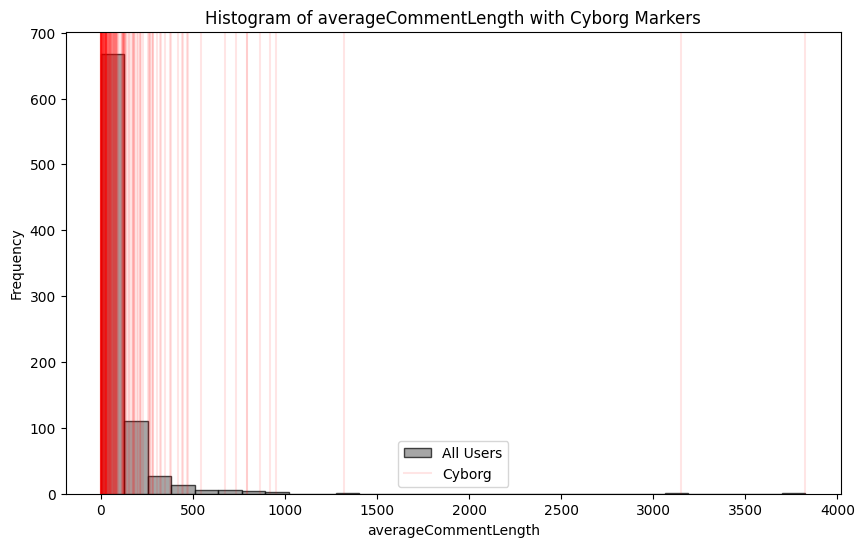

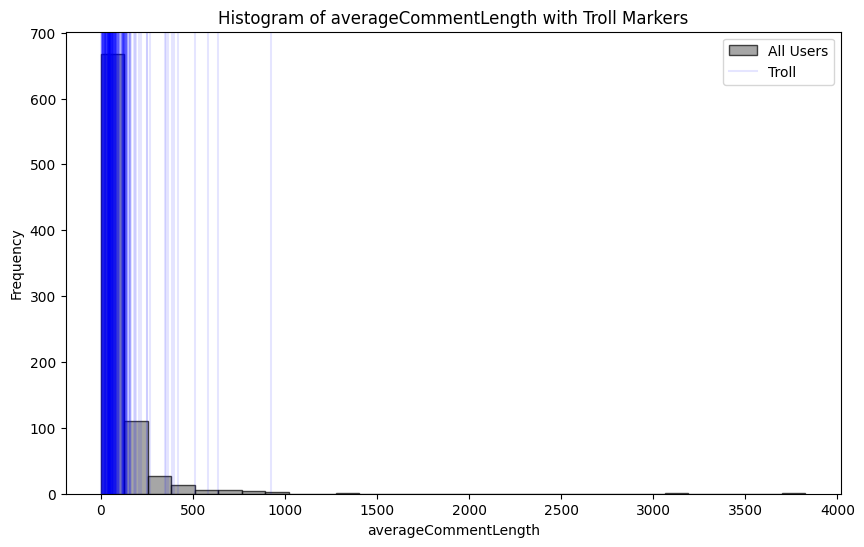

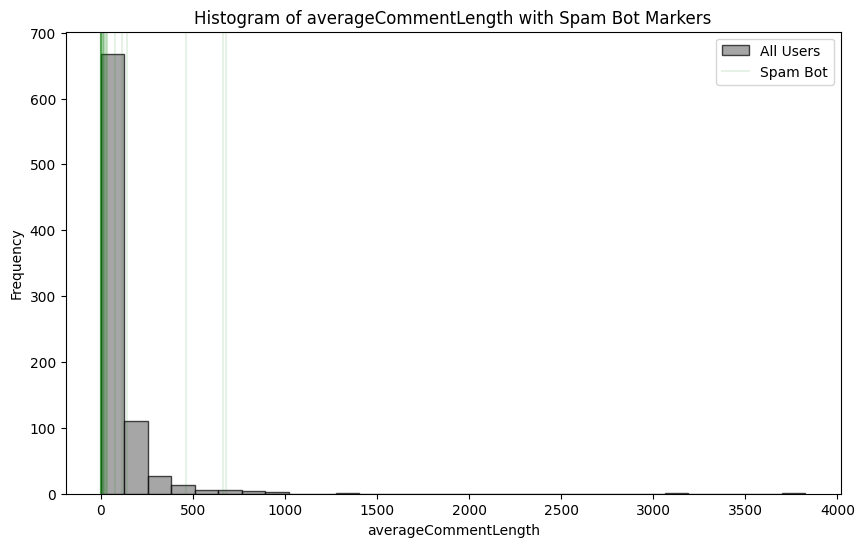

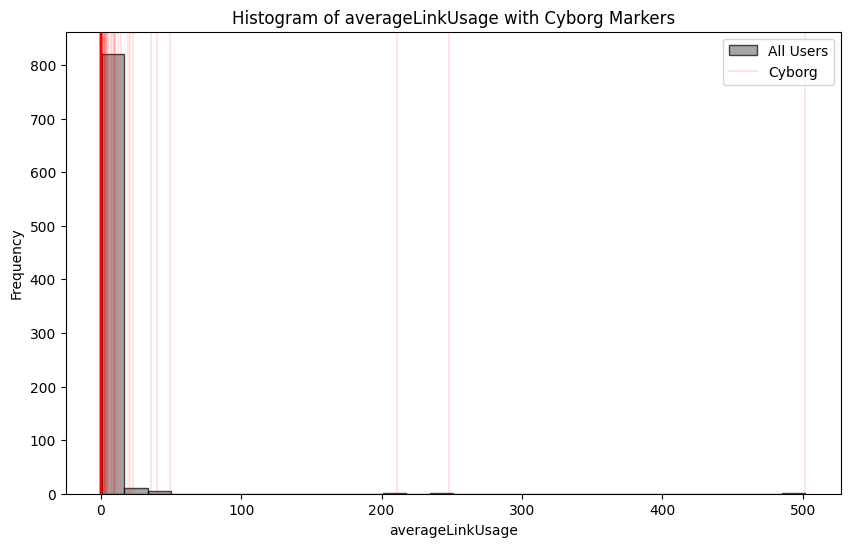

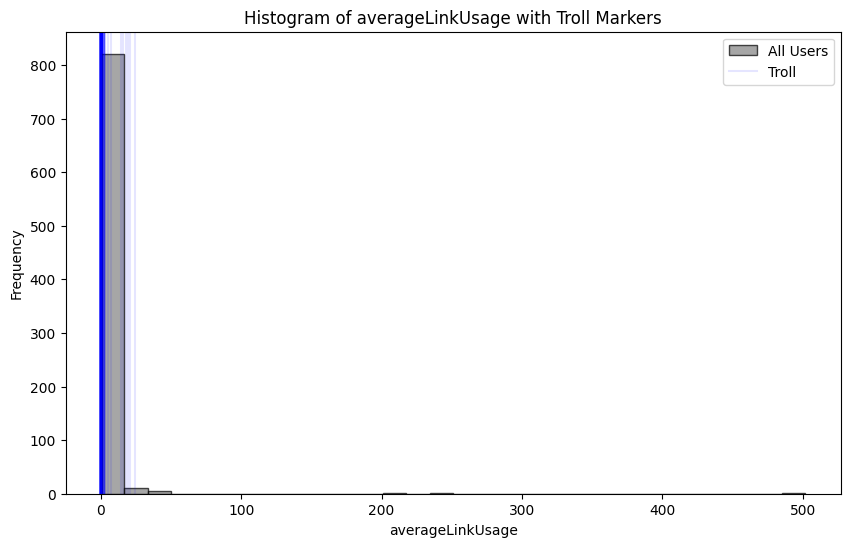

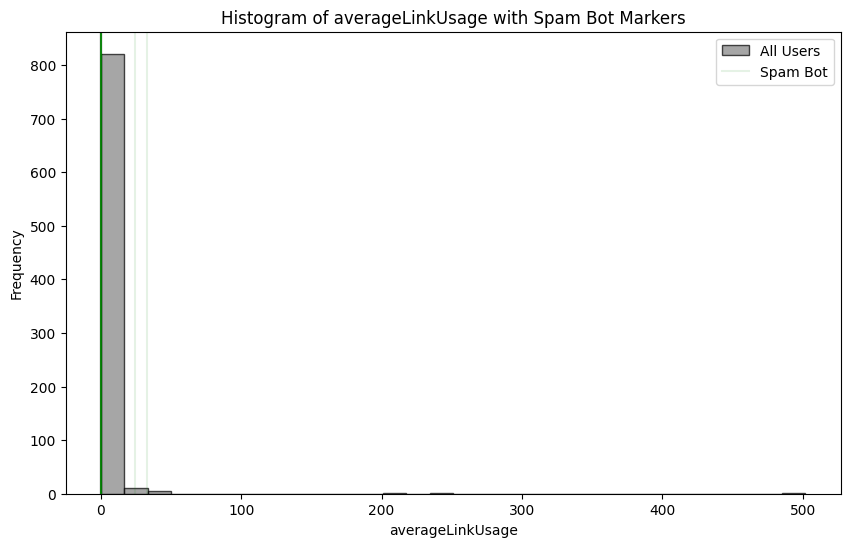

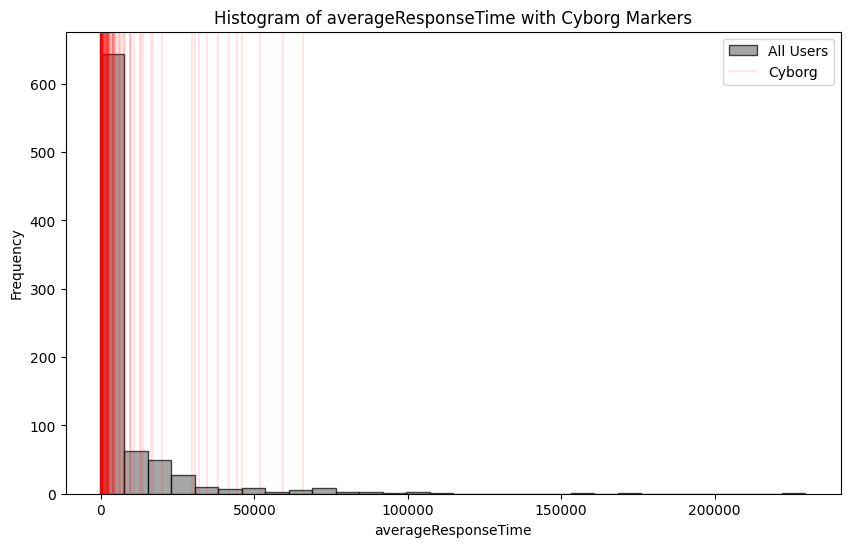

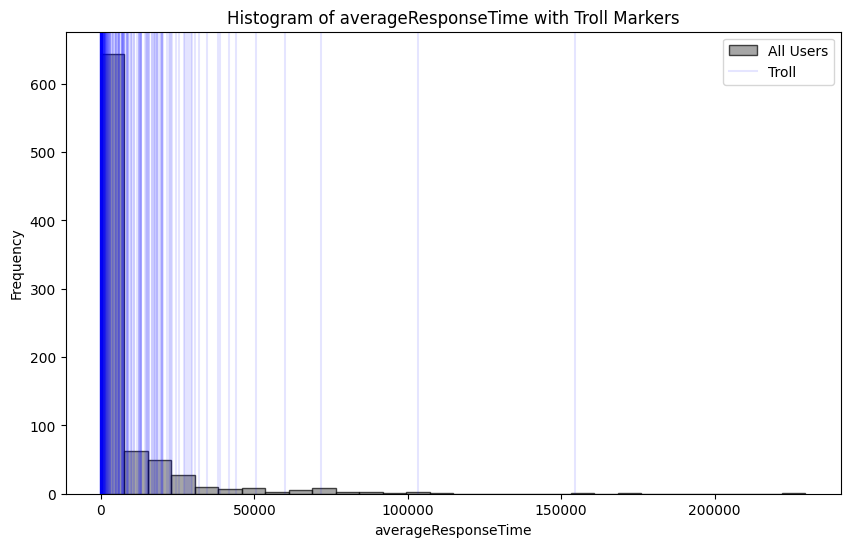

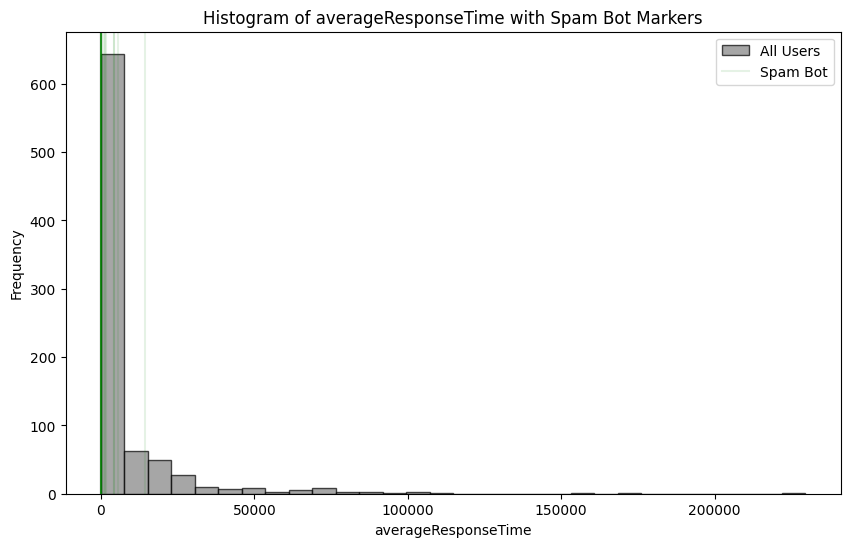

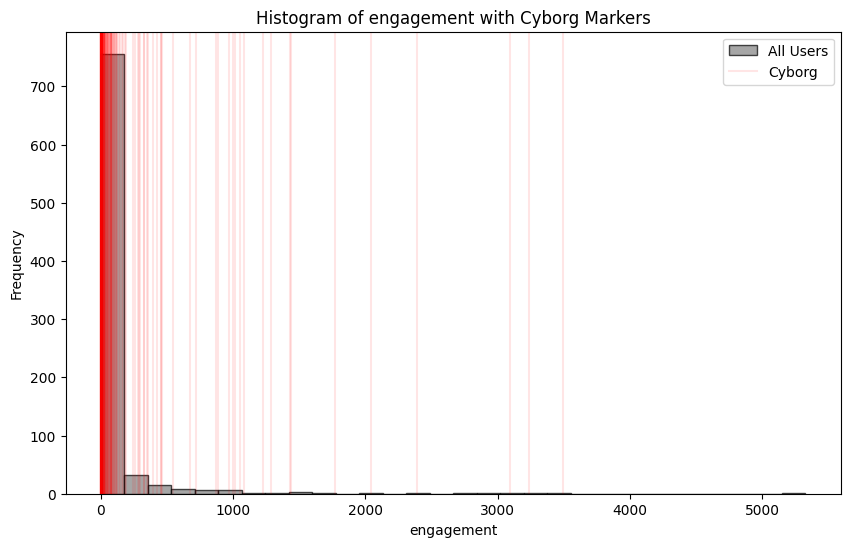

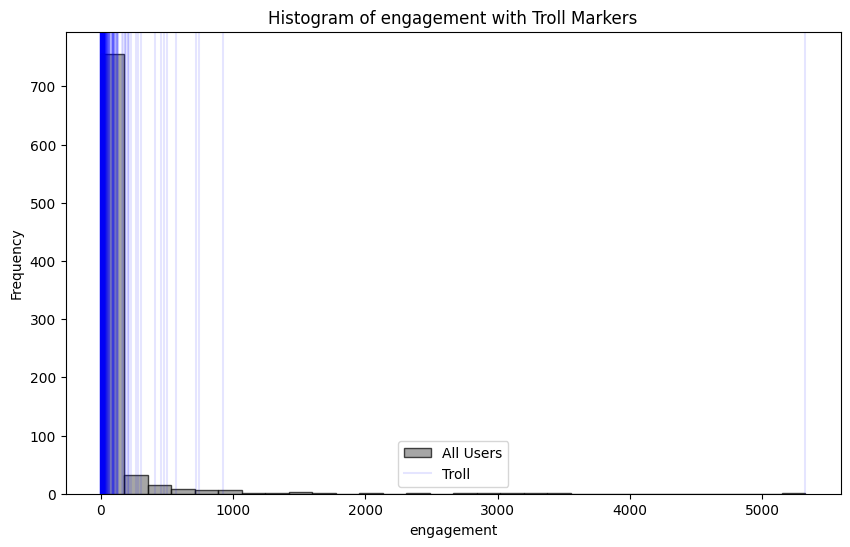

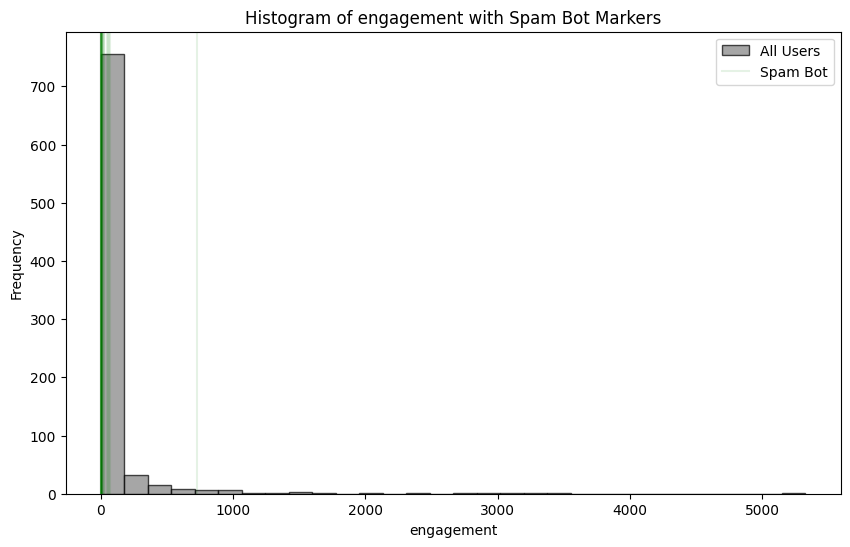

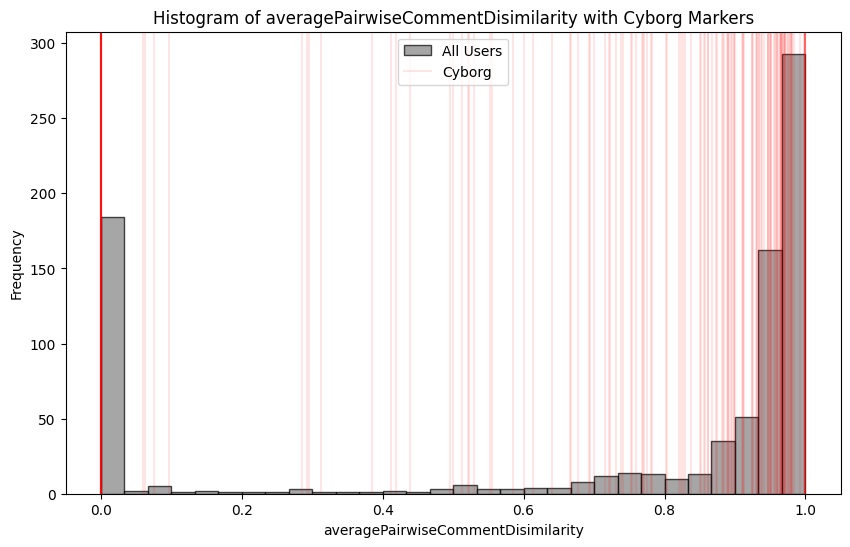

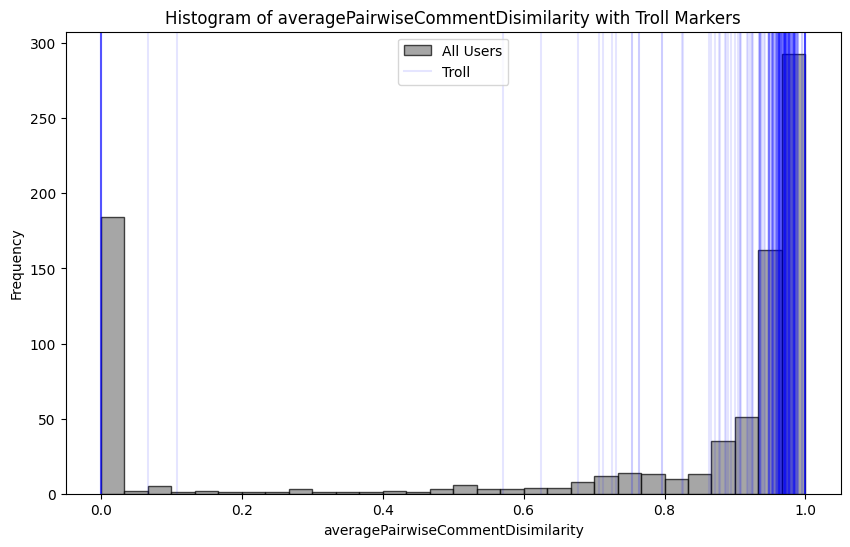

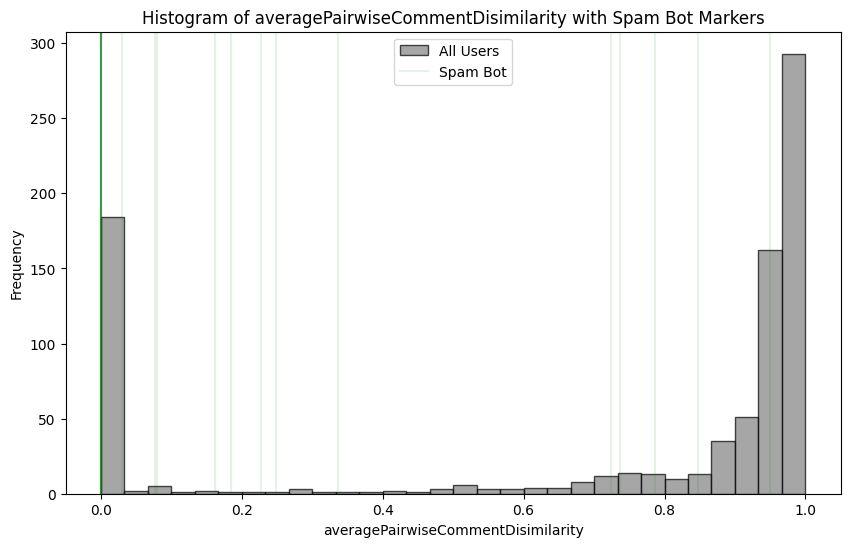

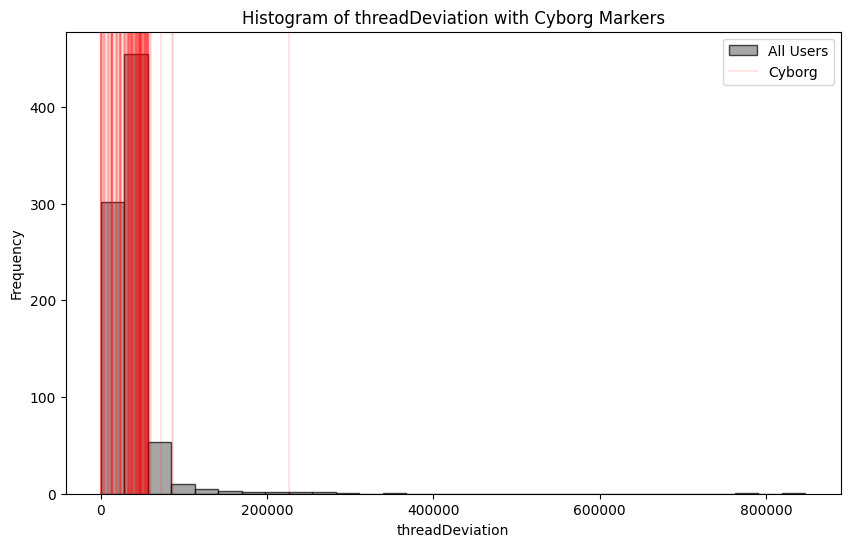

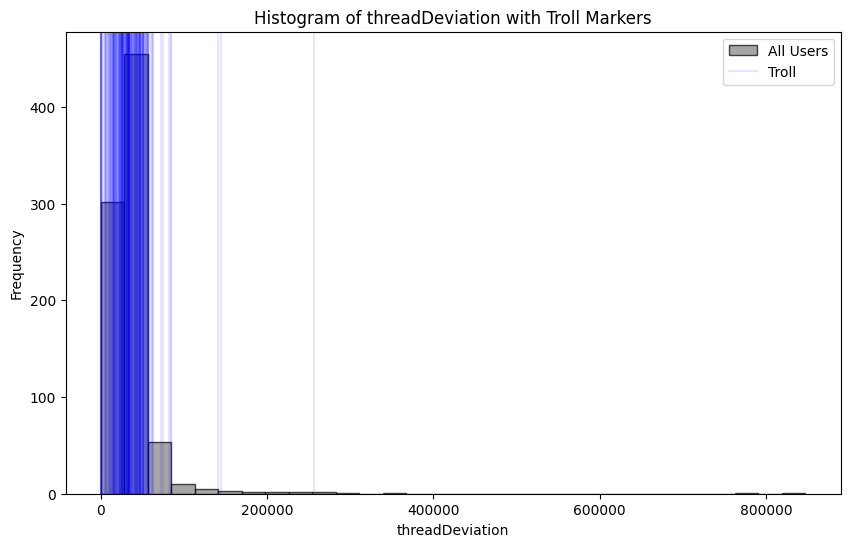

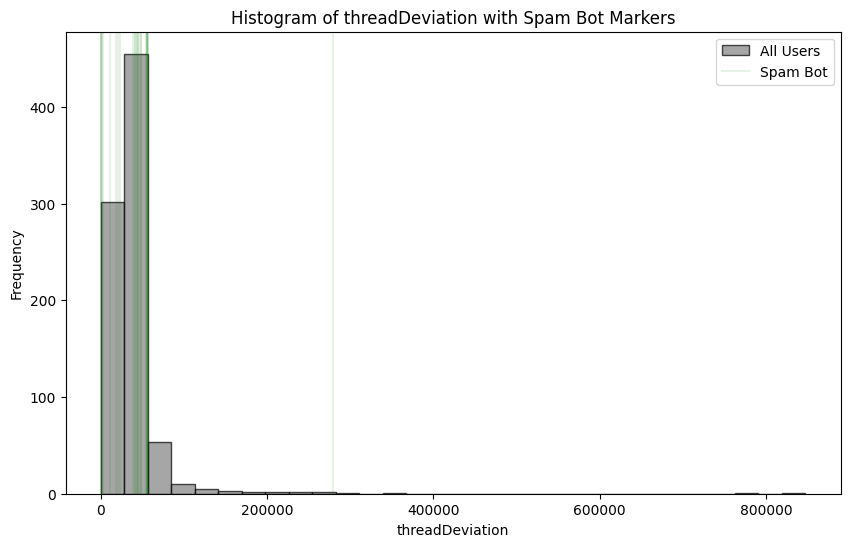

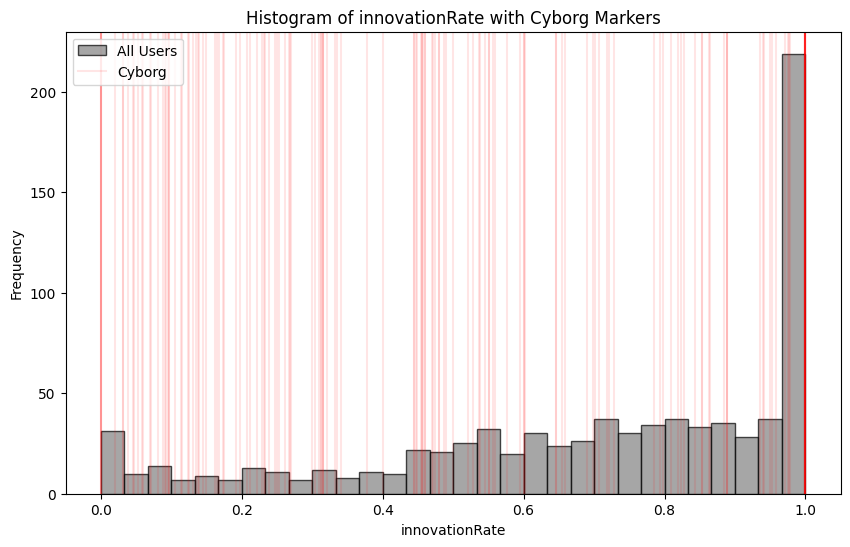

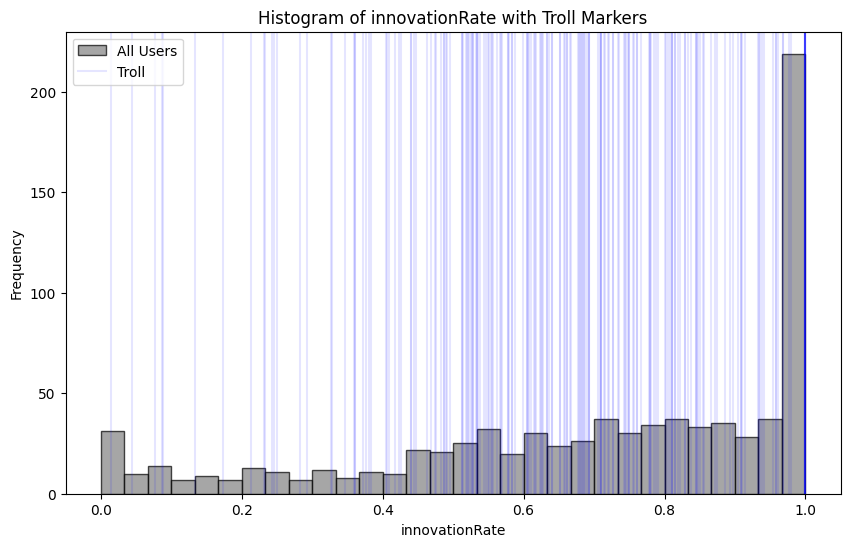

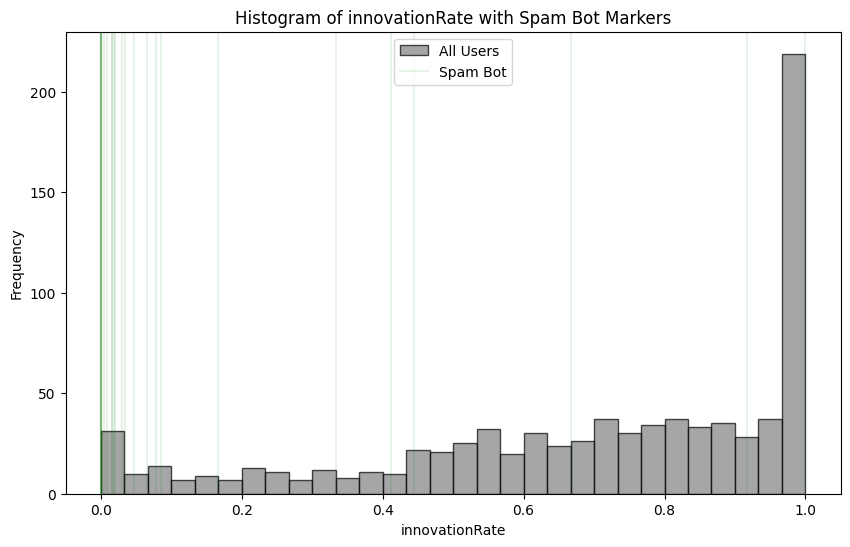

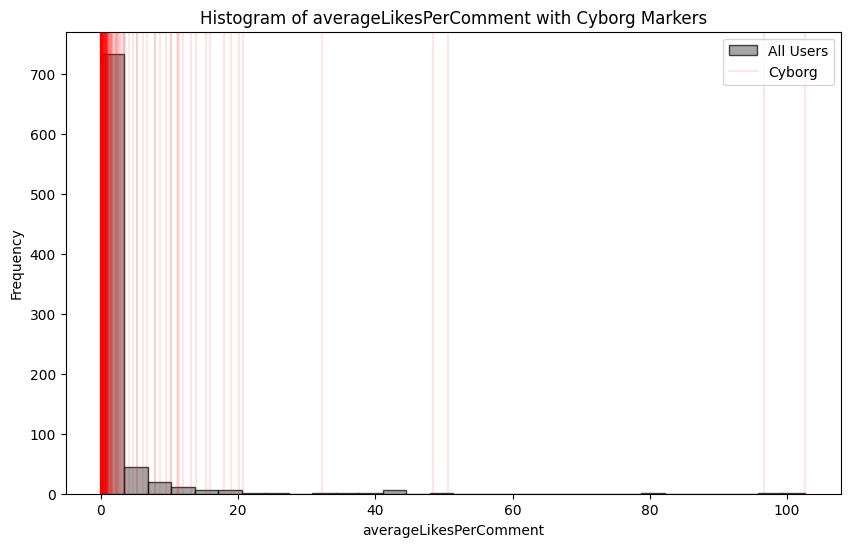

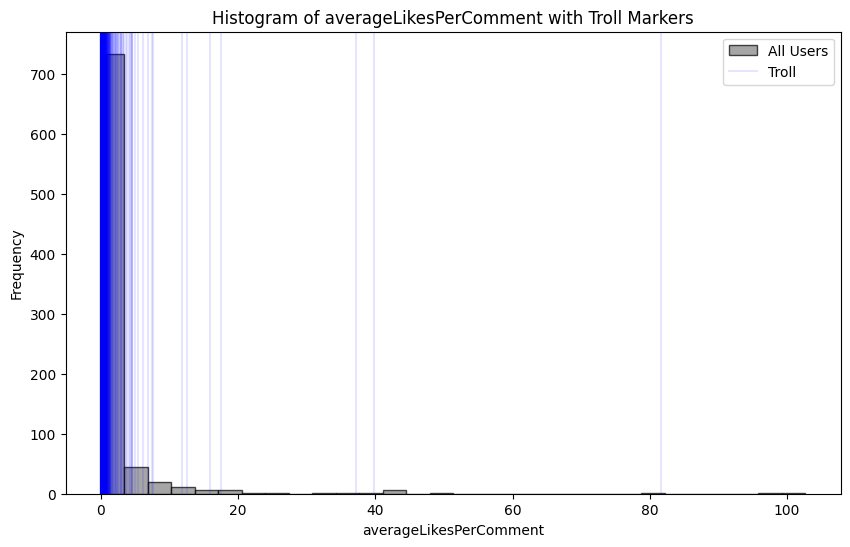

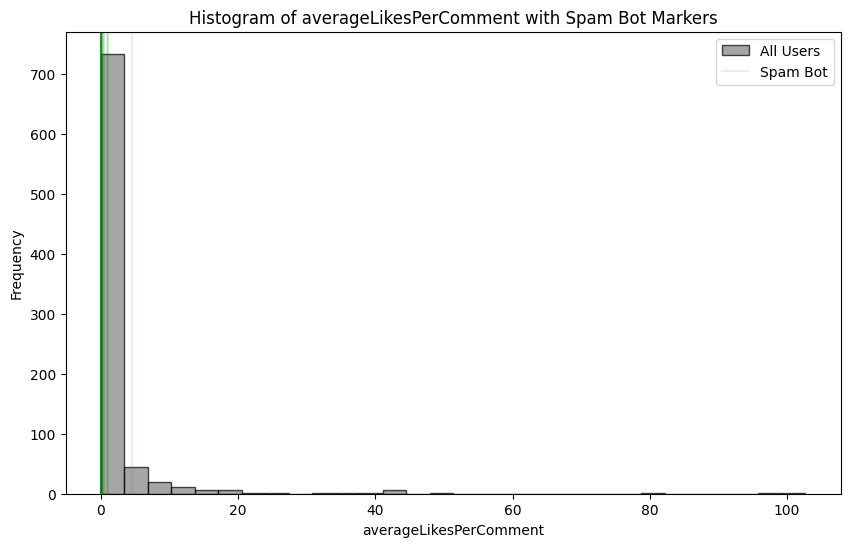

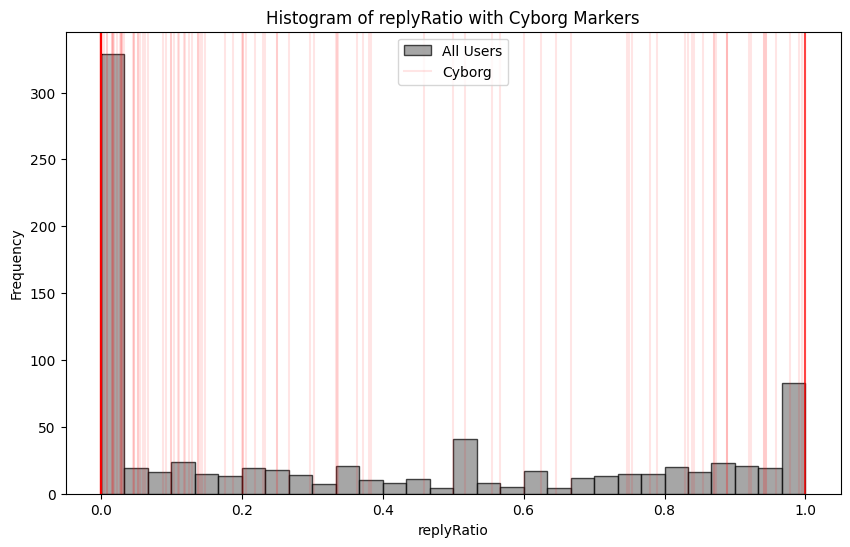

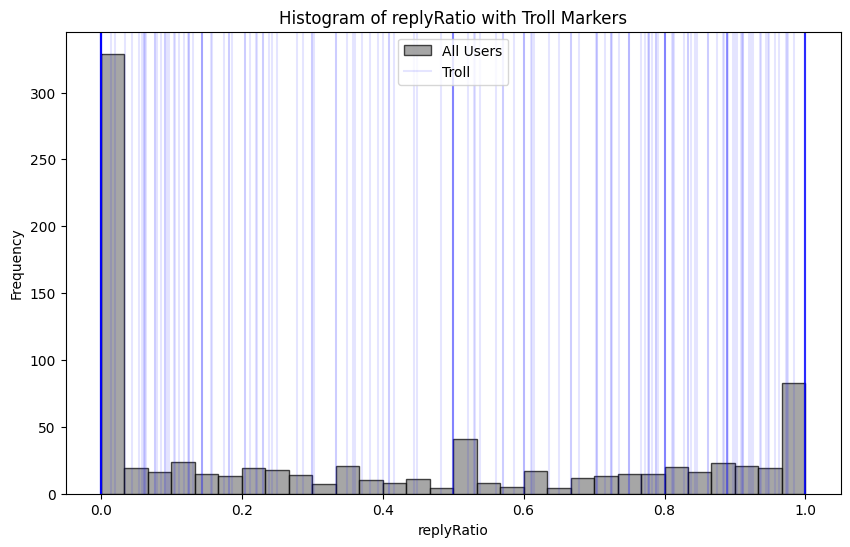

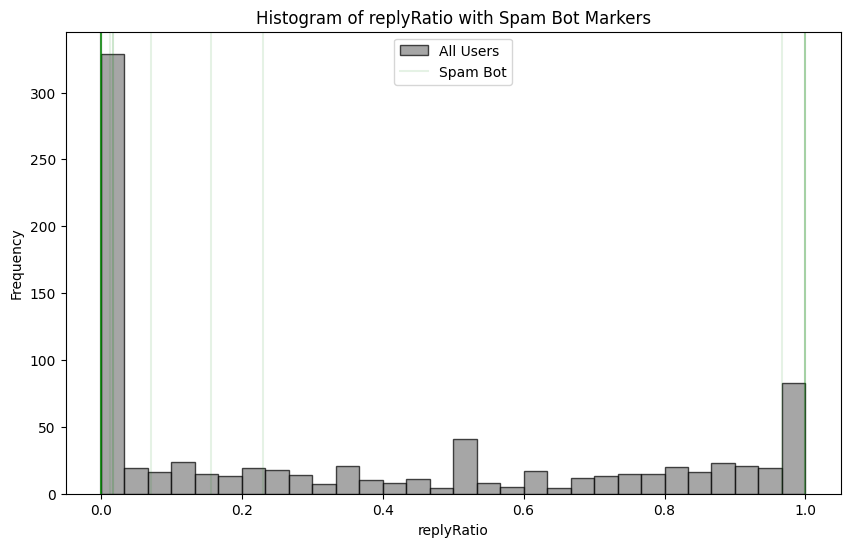

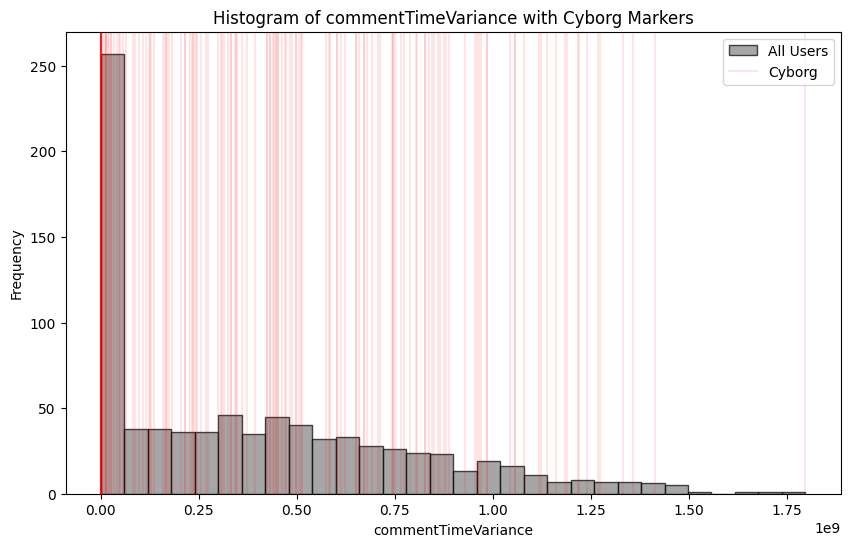

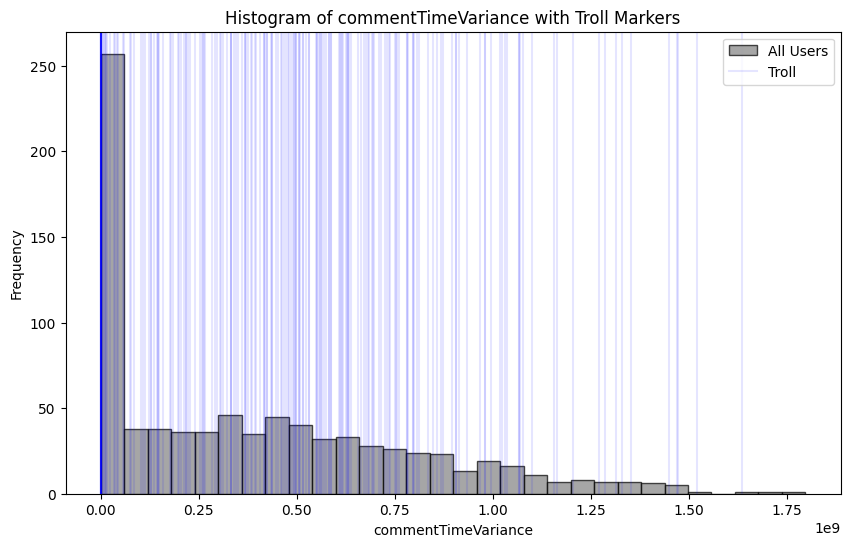

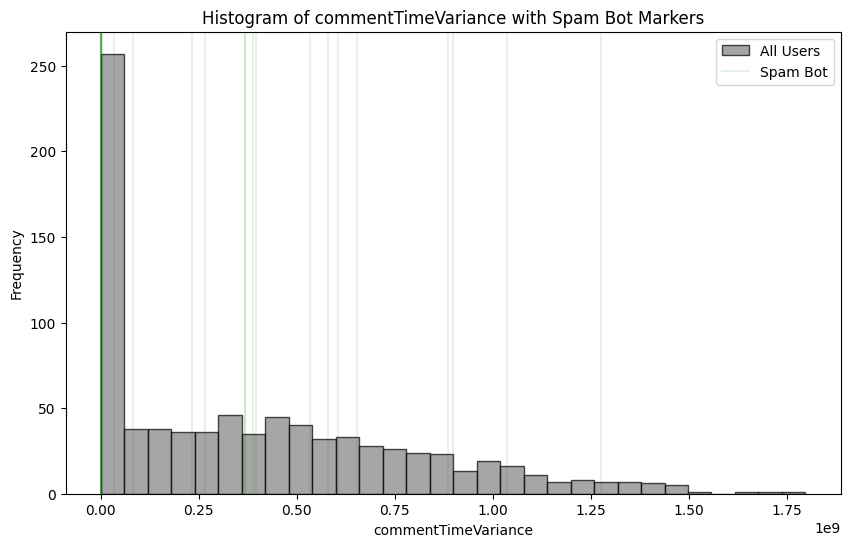

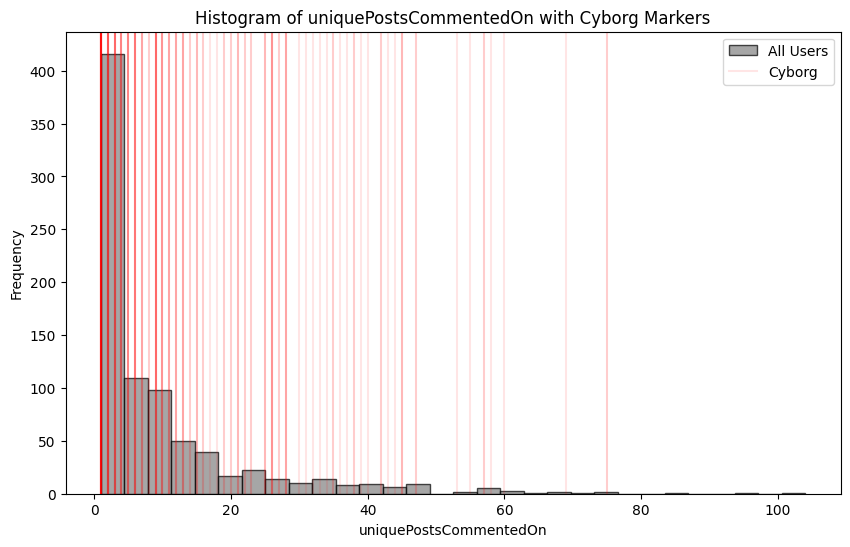

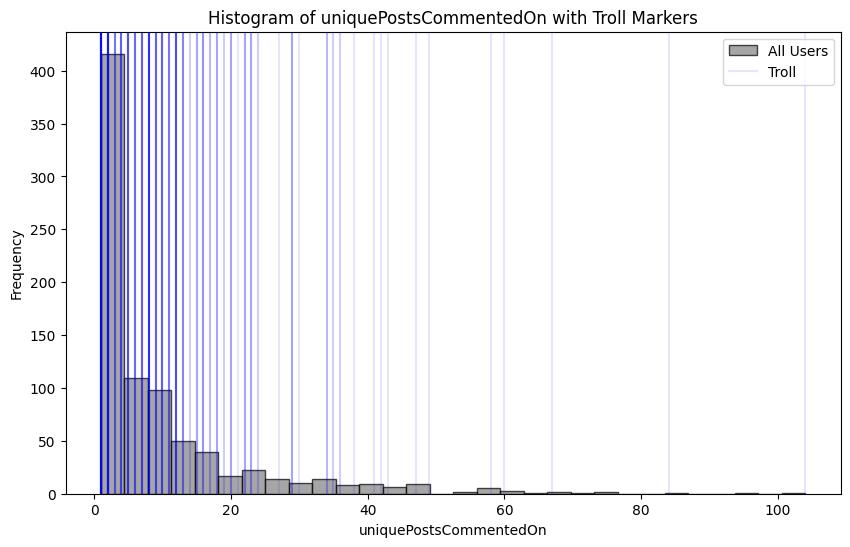

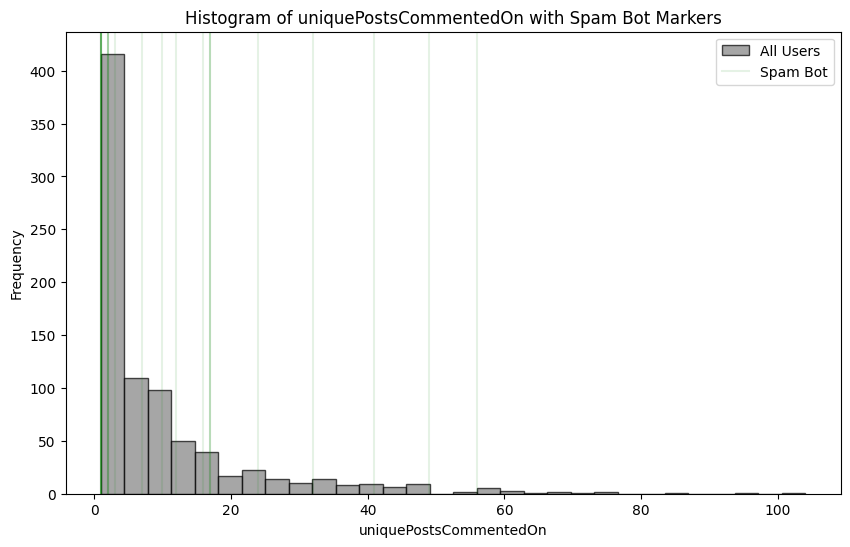

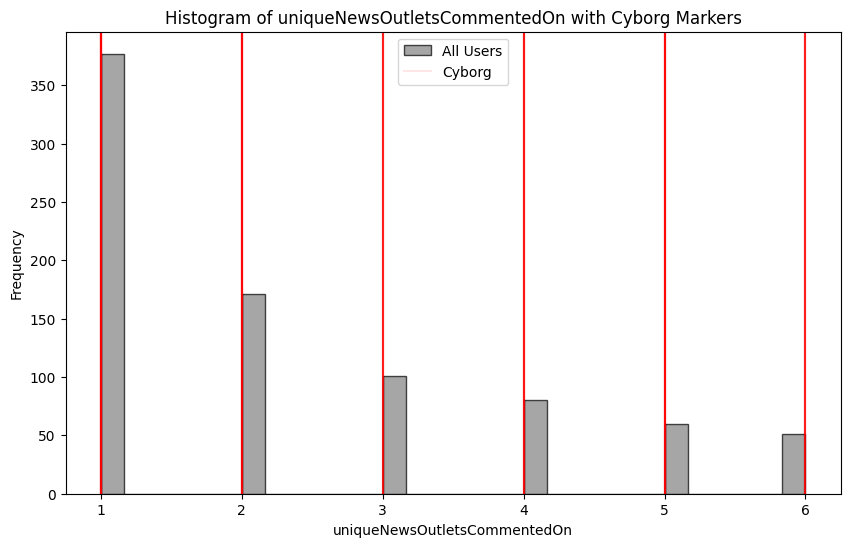

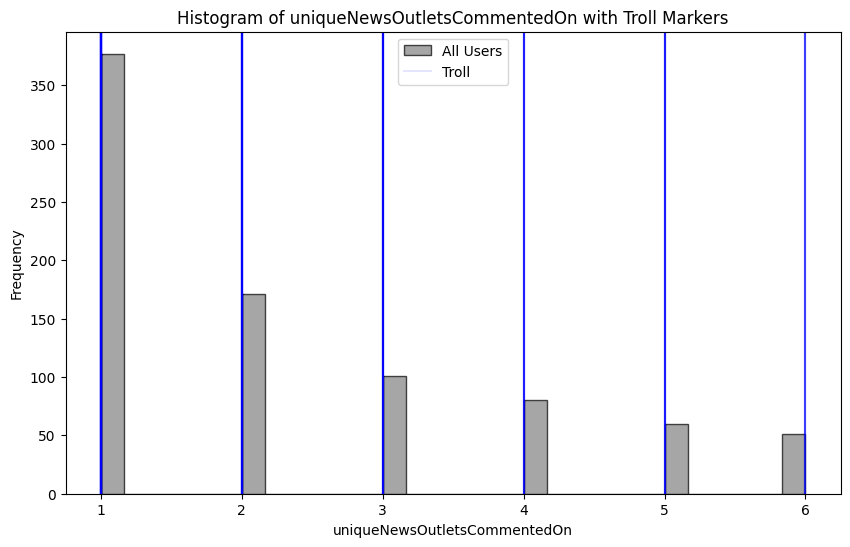

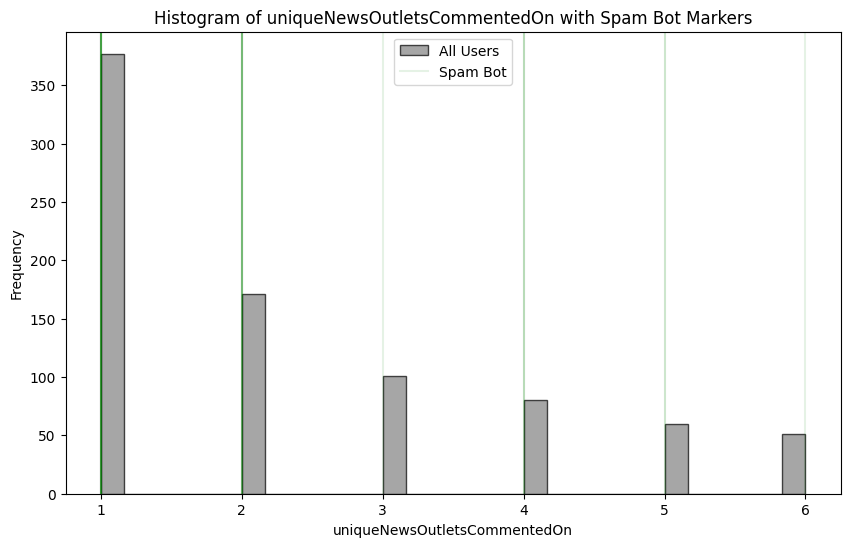

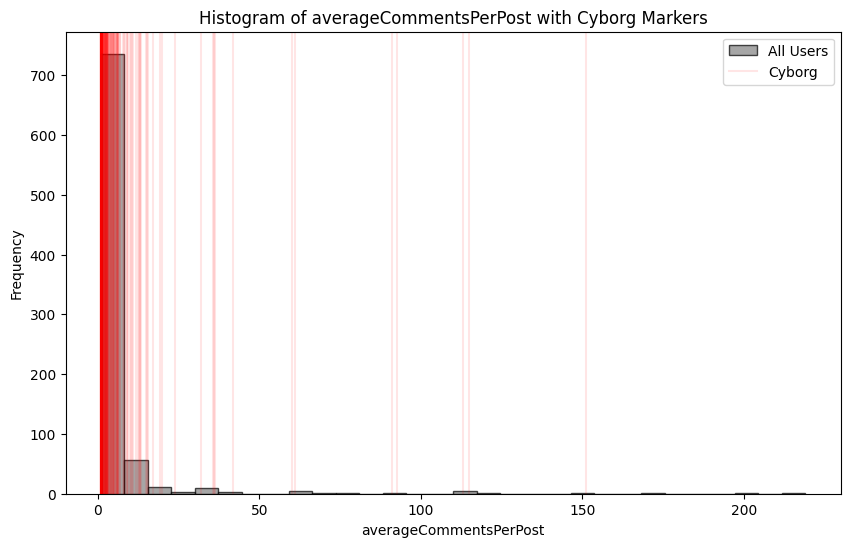

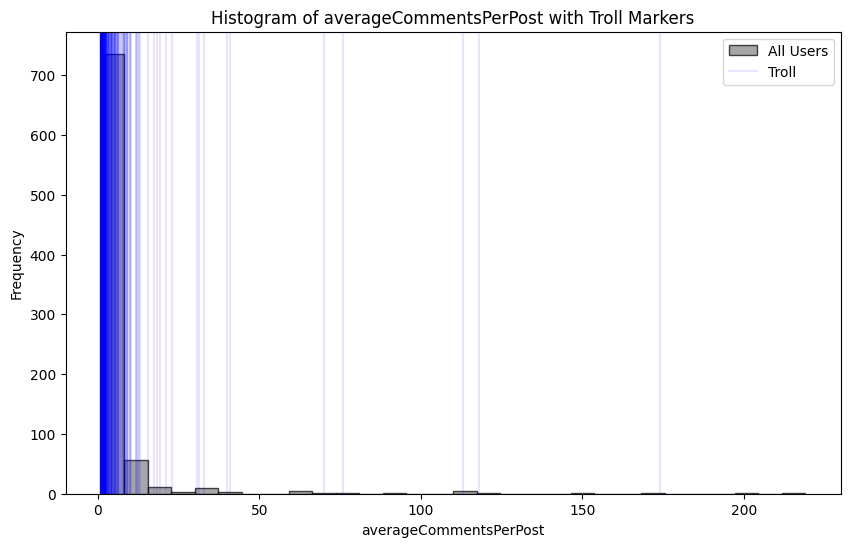

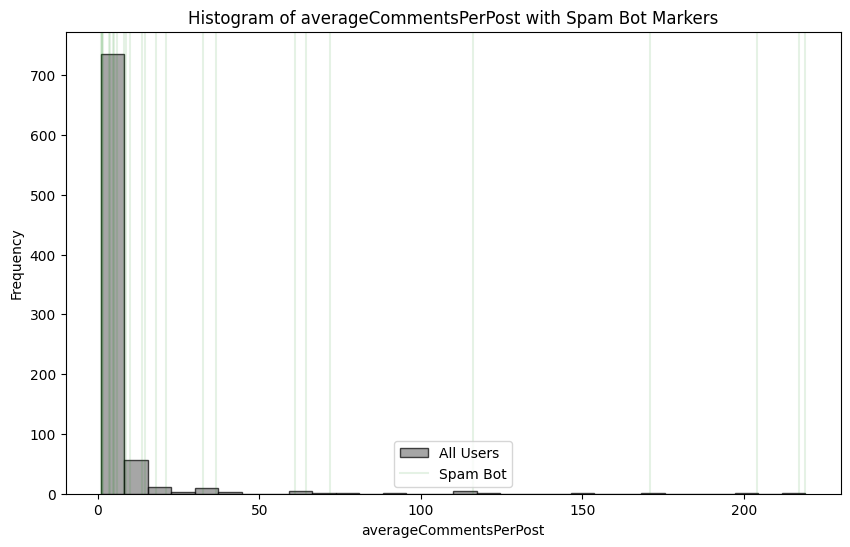

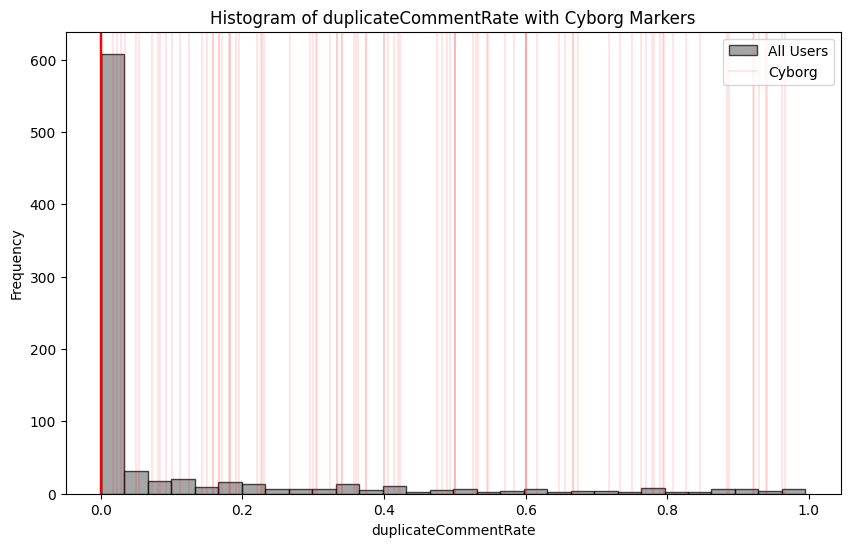

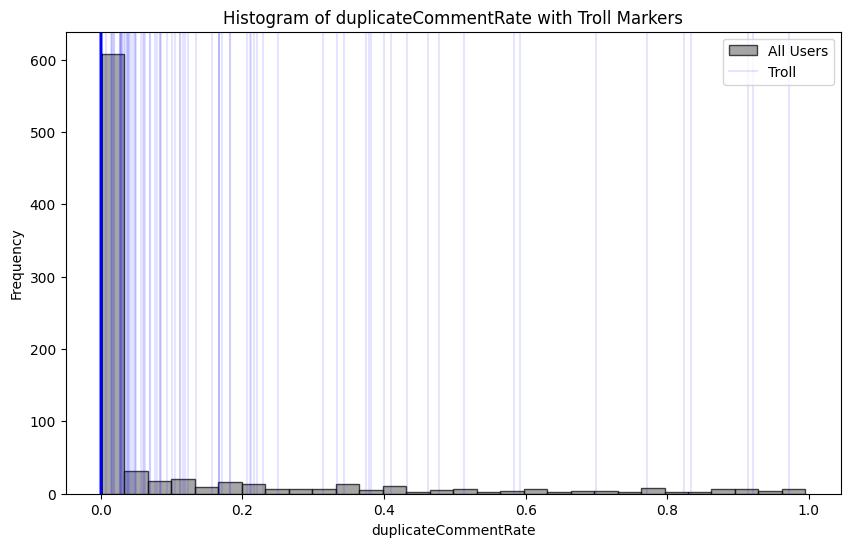

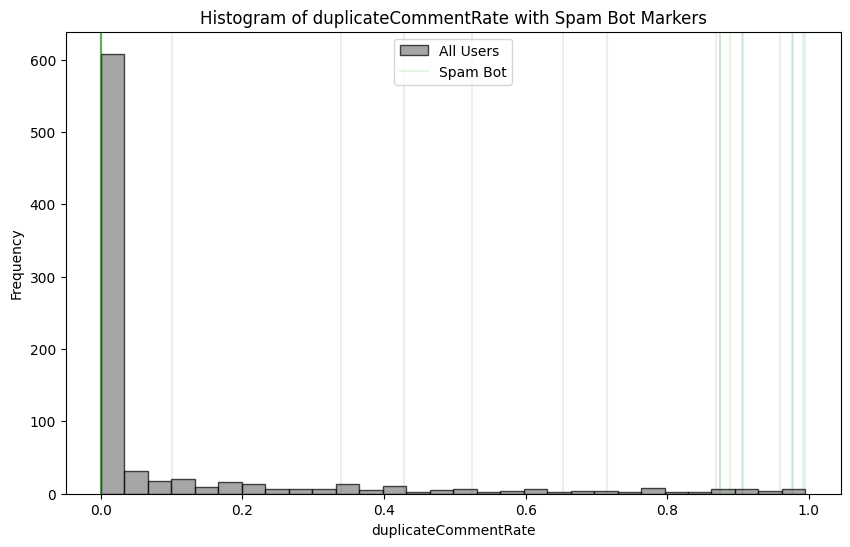

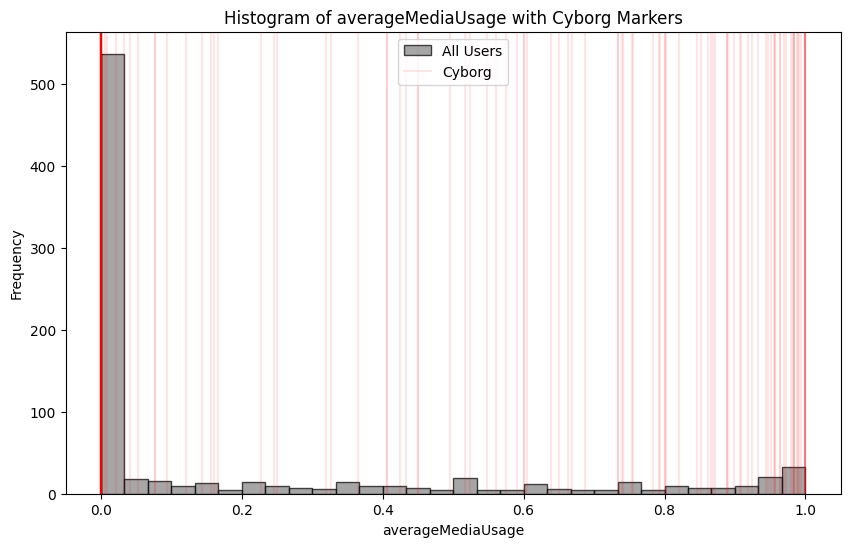

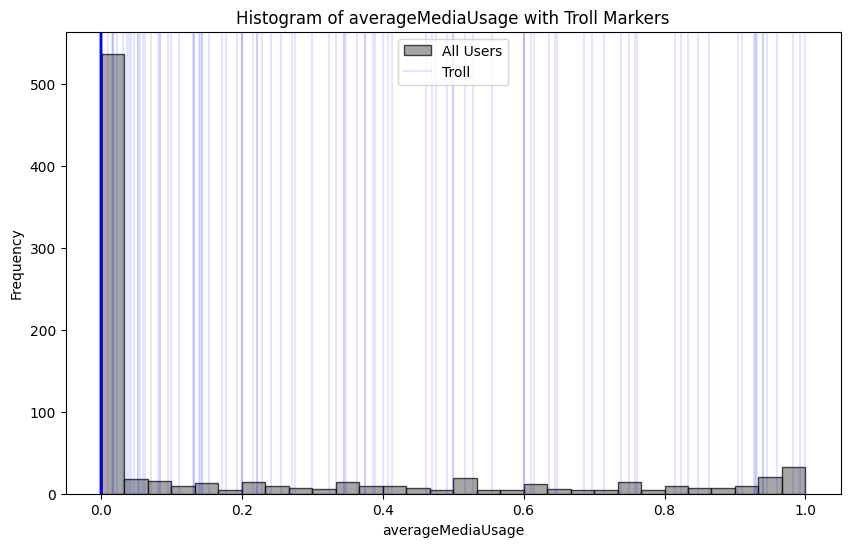

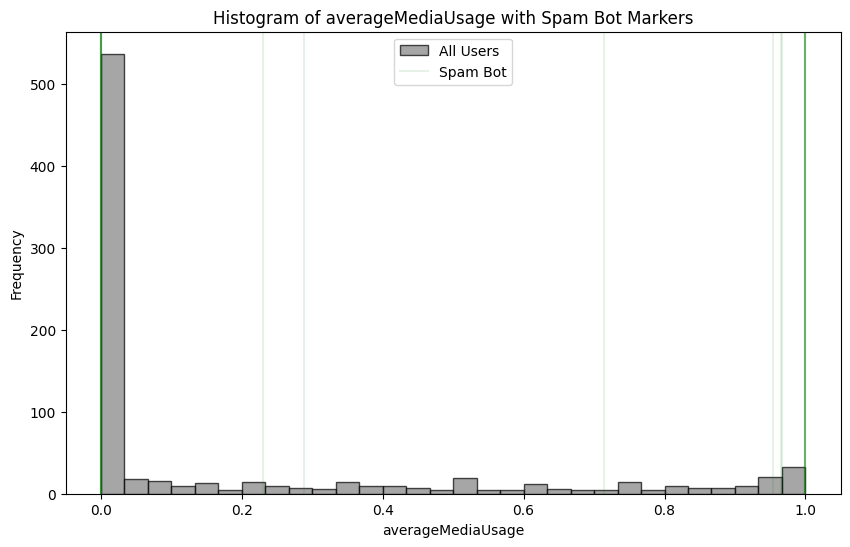

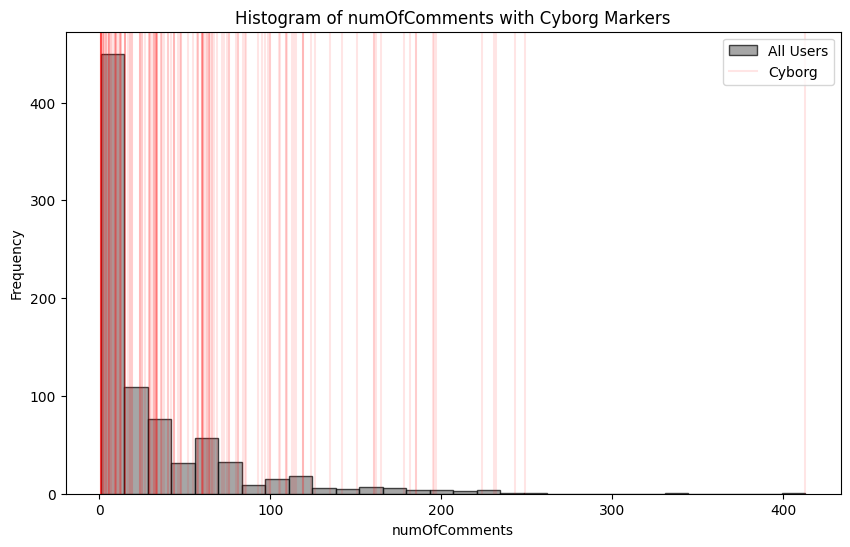

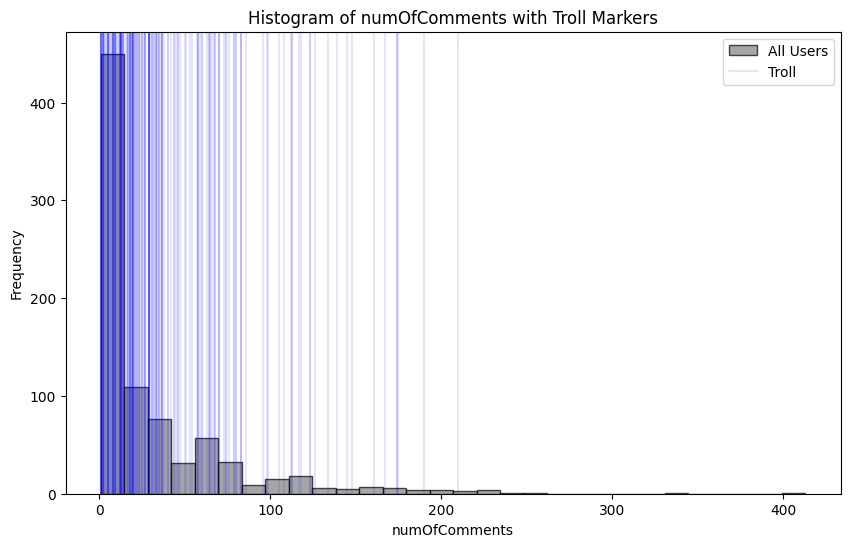

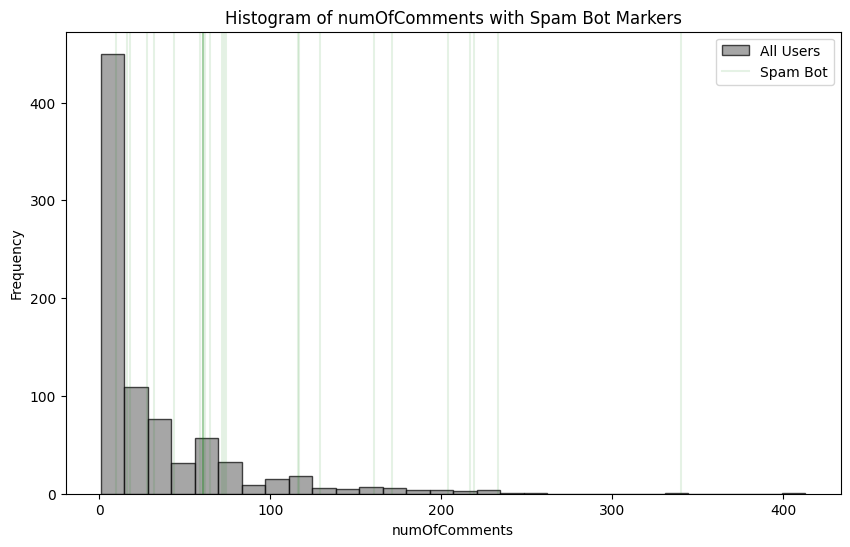

In [ ]:
feature_values = {}
special_indices = {"Cyborg": {}, "Troll": {}, "Spam Bot": {}}

for entry in data:
  if entry.get('label') is not None:
    if 'features' in entry:
        for feature, value in entry['features'].items():
            if value is not None:  # Ignore None values
                if feature not in feature_values:
                    feature_values[feature] = []
                    for label in special_indices:
                        special_indices[label][feature] = []

                feature_values[feature].append(value)

                if entry['label'] in special_indices:
                    special_indices[entry['label']][feature].append(len(feature_values[feature]) - 1)

# Define colors for different special labels
label_colors = {"Cyborg": "red", "Troll": "blue", "Spam Bot": "green"}

# Iterate over all features
for feature in feature_values.keys():
    # Generate separate histograms for each label
    for label in ["Cyborg", "Troll", "Spam Bot"]:
        plt.figure(figsize=(10, 6))

        # Plot the histogram of all users
        plt.hist(feature_values[feature], bins=30, alpha=0.7, edgecolor='black', color='gray', label="All Users")

        # Add vertical markers for the specific label
        for index in special_indices[label].get(feature, []):  # Handle cases where no values exist
            plt.axvline(feature_values[feature][index], color=label_colors[label], linestyle='solid', linewidth=1.5, alpha=0.1, label=label)

        # Ensure unique legend labels
        handles, labels = plt.gca().get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        plt.legend(unique_labels.values(), unique_labels.keys())

        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {feature} with {label} Markers")
        plt.show()

###**FIXING FILES**

In [ ]:
features_file = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook Comments (Features).json"
annotated_file = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Partially Annotated).json"

In [ ]:
import json

with open(annotated_file, 'r', encoding='utf-8') as infile:
    data = json.load(infile)
for user in data:
    user.pop("features", None)

with open(annotated_file, "w") as f:
    json.dump(data, f, indent=4)

print("Done")

Done


In [ ]:
with open(features_file, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Process each user entry
for user in data:
    num_comments = len(user.get("comments", []))
    user["features"]["numOfComments"] = num_comments
    user.pop("comments", None)  # Remove 'comments' field

# Save the updated JSON
with open(features_file, 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print("Done")

Done


In [ ]:
with open(features_file, 'r', encoding='utf-8') as infile:
    data = json.load(infile)

In [ ]:
label_path = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Facebook_Comments (Annotated).csv"

In [ ]:
import pandas as pd

df = pd.read_csv(label_path)
df = df.drop_duplicates(subset=["userID", "fin_lbl"])

In [ ]:
df.loc[:, ['userID', 'fin_lbl']].drop_duplicates(subset=['userID', 'fin_lbl']).dropna(subset=['fin_lbl'])

,userID,fin_lbl
0,3666779,Troll
1,9909248,Human
2,1539467,Cyborg
3,9384574,Human
4,2375700,Human
...,...,...
836,7684293,Human
837,5049404,Troll
838,9853748,Human
839,2427321,Human


In [ ]:
user_label_map = dict(zip(df["userID"].astype(str), df["fin_lbl"]))

In [ ]:
for entry in data:
    user_id = entry["userID"]
    if user_id in user_label_map:
        entry["label"] = user_label_map[user_id]

with open(features_file, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print("JSON file updated successfully!")

JSON file updated successfully!


In [ ]:
with open(annotated_file, 'r', encoding='utf-8') as infile:
    data = json.load(infile)

In [ ]:
news_outlets = set()

for user in data:
    for comment in user.get("comments", []):
        if "newsOutlet" in comment:
            news_outlets.add(comment["newsOutlet"])

# Print all found newsOutlet values
for outlet in sorted(news_outlets):
    print(outlet)

GMA
GMA News
Inquirer.net
Manila Bulletin
Philippine Star
Rappler
abscbn
gma


In [ ]:
# Normalize function
def normalize_news_outlet(outlet):
    if outlet is None:
        return outlet
    outlet_lower = outlet.lower()
    if outlet_lower == "gma":
        return "GMA News"
    elif outlet_lower == "abscbn":
        return "ABS-CBN"
    return outlet  # leave unchanged

# Normalize newsOutlet in all comments
for user in data:
    for comment in user.get("comments", []):
        if "newsOutlet" in comment:
            comment["newsOutlet"] = normalize_news_outlet(comment["newsOutlet"])


In [ ]:
news_outlets = {comment["newsOutlet"] for user in data for comment in user["comments"] if "newsOutlet" in comment}
print("Unique news outlets after normalization:")
for outlet in sorted(news_outlets):
    print(outlet)

Unique news outlets after normalization:
ABS-CBN
GMA News
Inquirer.net
Manila Bulletin
Philippine Star
Rappler


In [ ]:
for user in data:

    # Compute feature
    unique_outlet_count = compute_unique_outlets_commented_on(user.get("comments", []))

    # Add to features dict
    user["features"] = {
        "uniqueNewsOutletsCommentedOn": unique_outlet_count
    }


In [ ]:
with open(annotated_file, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

In [ ]:
with open(annotated_file, 'r', encoding='utf-8') as infile:
    json1 = json.load(infile)

In [ ]:
with open(features_file, 'r', encoding='utf-8') as infile:
    json2 = json.load(infile)

In [ ]:
news_outlet_map = {
    user['userID']: user['features']['uniqueNewsOutletsCommentedOn']
    for user in json1 if 'features' in user and 'uniqueNewsOutletsCommentedOn' in user['features']
}

# Update json2 with the value from json1
for user in json2:
    user_id = user['userID']
    if user_id in news_outlet_map:
        user['features']['uniqueNewsOutletsCommentedOn'] = news_outlet_map[user_id]

# Remove 'features' from json1
for user in json1:
    user.pop('features', None)

In [ ]:
with open(features_file, 'w') as f2_out, open(annotated_file, 'w') as f1_out:
    json.dump(json2, f2_out, indent=4, ensure_ascii=False)
    json.dump(json1, f1_out, indent=4, ensure_ascii=False)